[WARN] [1743758439.365209080] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
2025-04-04 11:20:39 robo-pc-005 rai.utils.model_initialization[148097] INFO Initializing complex_model: Vendor: openai, Model: gpt-4o
2025-04-04 11:20:42 robo-pc-005 httpx[148097] INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


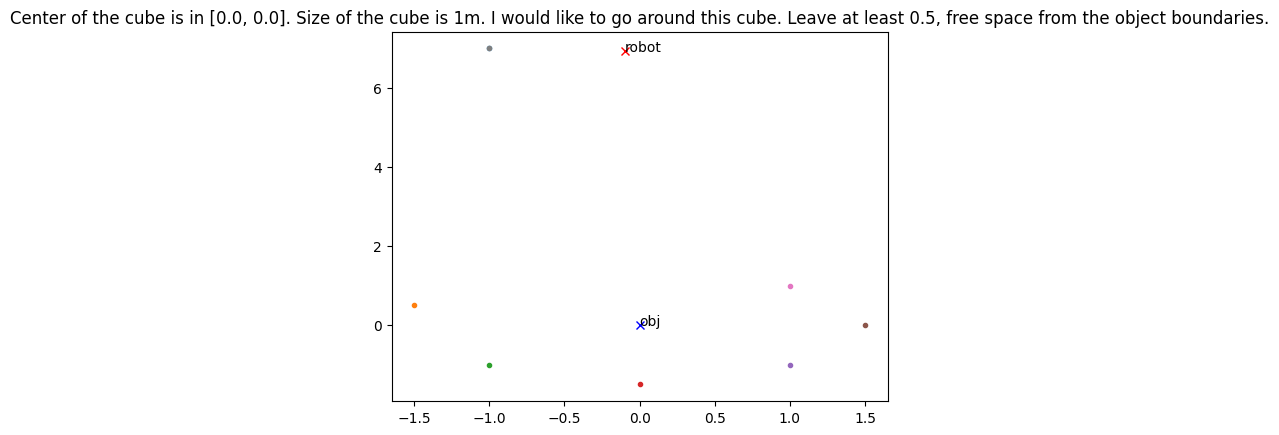

2025-04-04 11:20:43 robo-pc-005 rai.utils.model_initialization[148097] INFO Initializing complex_model: Vendor: openai, Model: gpt-4o
2025-04-04 11:20:45 robo-pc-005 httpx[148097] INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


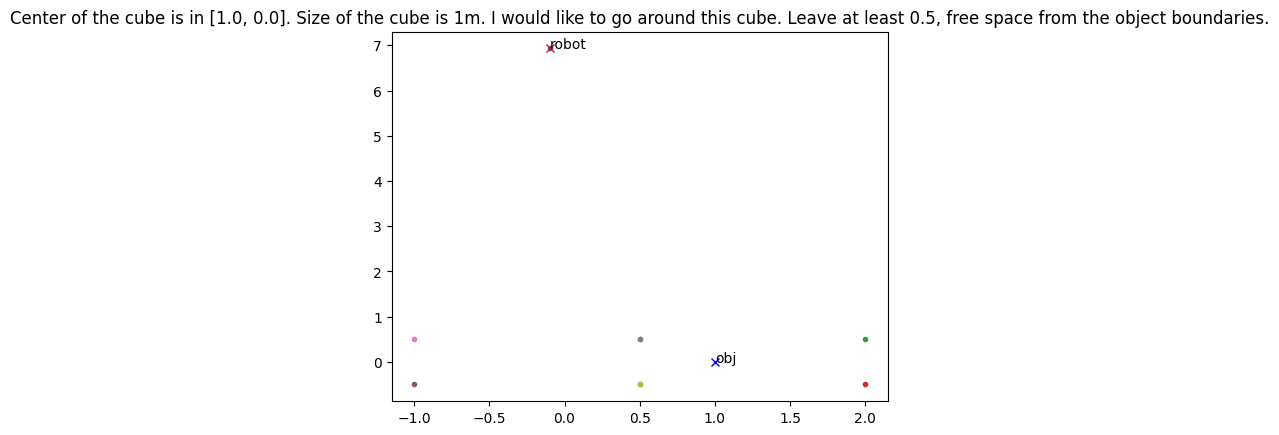

2025-04-04 11:20:46 robo-pc-005 rai.utils.model_initialization[148097] INFO Initializing complex_model: Vendor: openai, Model: gpt-4o
2025-04-04 11:20:49 robo-pc-005 httpx[148097] INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


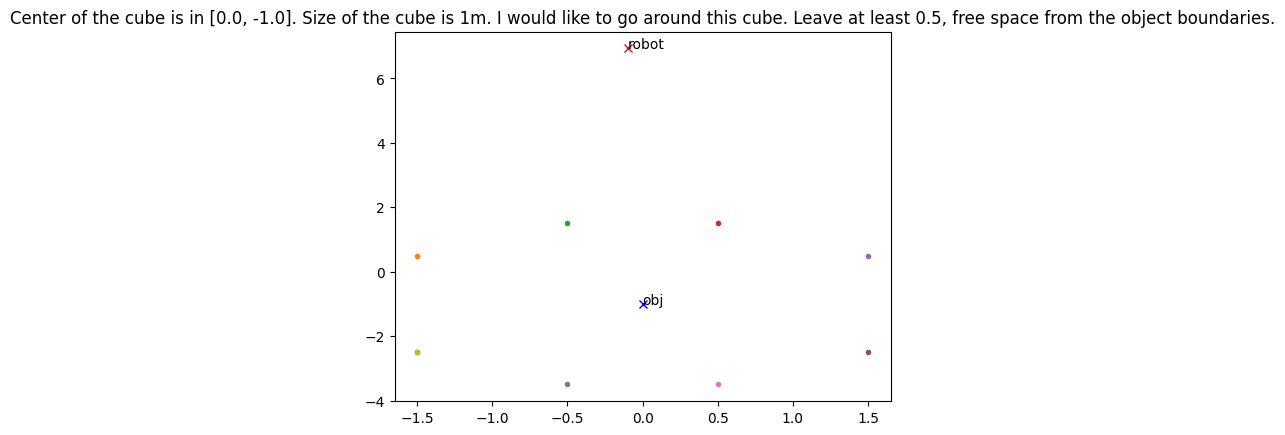

2025-04-04 11:20:50 robo-pc-005 rai.utils.model_initialization[148097] INFO Initializing complex_model: Vendor: openai, Model: gpt-4o
2025-04-04 11:20:52 robo-pc-005 httpx[148097] INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


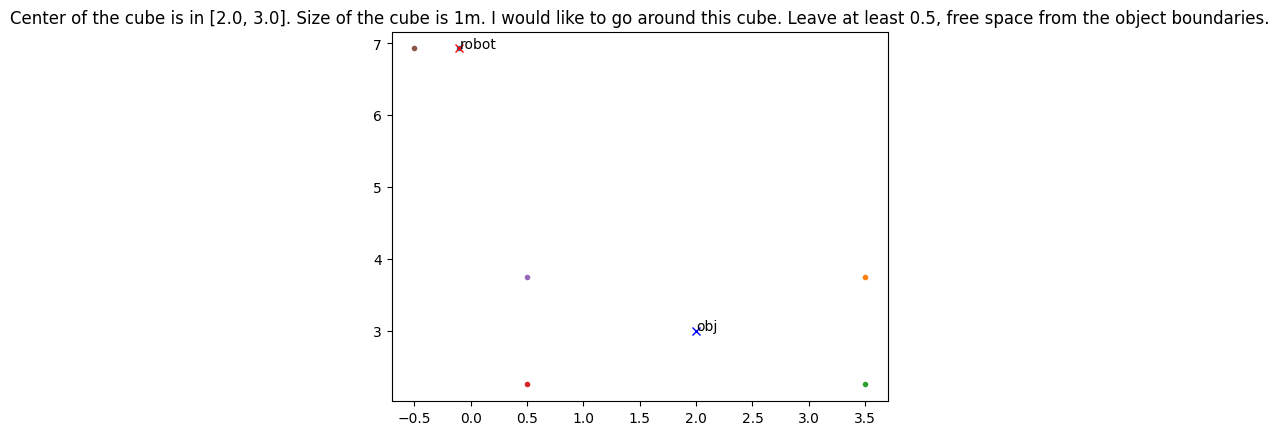

2025-04-04 11:20:52 robo-pc-005 rai.utils.model_initialization[148097] INFO Initializing complex_model: Vendor: openai, Model: gpt-4o
2025-04-04 11:20:54 robo-pc-005 httpx[148097] INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


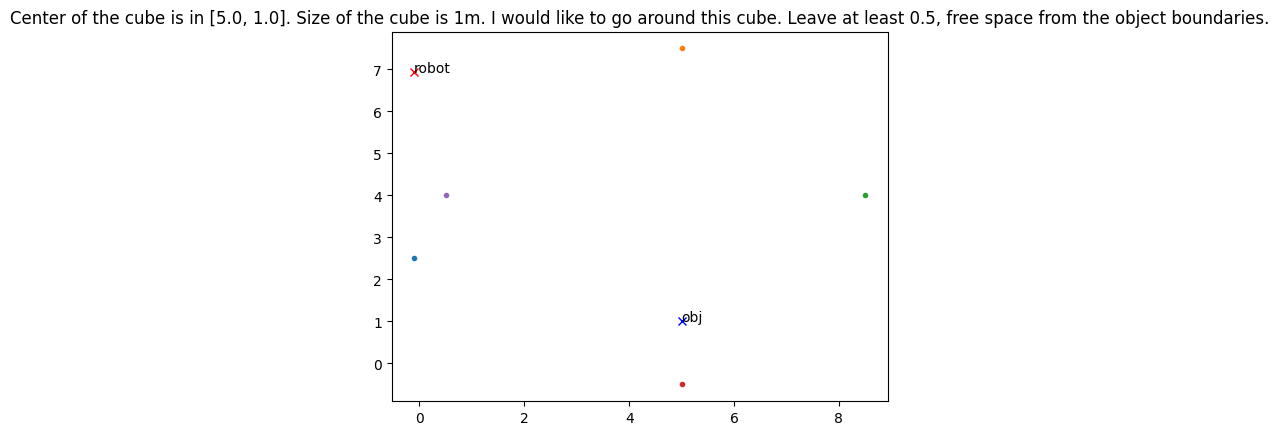

In [29]:
# Copyright (C) 2025 Robotec.AI
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#         http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from typing import Tuple, cast, List

from numpy import outer
import rclpy
import rclpy.executors
import rclpy.logging
import matplotlib.pyplot as plt

from pydantic import BaseModel, Field
# import streamlit as st
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import render_text_description_and_args, tool
from rai.agents.conversational_agent import create_conversational_agent
from rai.communication.ros2 import ROS2ARIConnector
from rai.messages import HumanMultimodalMessage
from rai.tools.ros.manipulation import GetObjectPositionsTool
from rai.tools.ros2 import (
    GetROS2ImageTool,
    GetROS2TransformTool,
)
from rai.tools.ros2.nav2 import (
    CancelNavigateToPoseTool,
    GetNavigateToPoseFeedbackTool,
    GetNavigateToPoseResultTool,
    NavigateToPoseTool,
)
from rai.utils.model_initialization import get_llm_model, get_tracing_callbacks
from rai_open_set_vision.tools import GetGrabbingPointTool
from rai.tools.ros.nav2.basic_navigator import quat2eulers
from tf2_ros import TransformStamped


class ResponseFormatter(BaseModel):
    """Always use this tool to structure your response to the user."""
    poses: List[List[float]] = Field(description="List (x,y,yaw) coordinates - i.e list of poses to accomplish the task. Yaw is an angle of the robot in radians. When yaw=0, and robot is moving forward, only y coordinate will increase. x and y are in meters.")
    possible: bool = Field(description="If task is possible")

connector = ROS2ARIConnector()
transform_tool = GetROS2TransformTool(connector=connector)
@tool
def spatial_reasoning(query: str) -> ResponseFormatter:
    """ Tool that returns a list of poses to achieve the query """ 
    llm = get_llm_model("complex_model")

    tf: TransformStamped = transform_tool._run(
        source_frame="base_link", target_frame="map", timeout_sec=5.0
    )
    x = round(tf.transform.translation.x, 2)
    y = round(tf.transform.translation.y, 2)

    q = tf.transform.rotation
    _,_,yaw = quat2eulers(q.x,q.y,q.z,q.w)
    yaw = round(yaw, 2)
    cur_location = {"x": x, "y": y, "yaw": yaw}

    system_prompt = """You are an expert in spatial reasoning and robot navigation. Your task is to determine the sequence of poses where robot should go to accomplish given task.
    You will be given a task, current position and possible possitions of other objects. All coordinates are in the map frame."""

    llm = llm.with_structured_output(ResponseFormatter)
    task = [
        SystemMessage(content=system_prompt),
        HumanMultimodalMessage(
            content=f"Your current location is: {cur_location}. The task is to {query}",
        )
    ]
    output: ResponseFormatter = llm.invoke(task, config={"callbacks": []})
    return output, cur_location


object_loc = [
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, -1.0],
    [2.0, 3.0],
    [5.0, 1.0],
]
obj_size = 1
margin = 0.5
for a,b in object_loc:
    query = f'Center of the cube is in [{a}, {b}]. Size of the cube is {obj_size}m. I would like to go around this cube. Leave at least {margin}, free space from the object boundaries.'
    output,cur_location = spatial_reasoning.invoke({'query' : query})
    plt.figure()
    plt.title(query)
    for p in output.poses:
        plt.plot(p[0], p[1], '.')
    plt.text(a, b, 'obj')
    plt.plot(a, b, 'x', color='blue')
    plt.text(cur_location['x'], cur_location['y'], 'robot')
    plt.plot(cur_location['x'], cur_location['y'], 'x', color='red')
    plt.savefig(f'cube_center_{a}-{b}.png')
    plt.show()
    